# Total Lunar Eclipse — Cinematic Educational Shorts Notebook

This is a **specific-event** notebook for one topic: **a total lunar eclipse**.

It generates a polished vertical info video with:

- Sun–Earth–Moon alignment visuals
- Earth's umbra and penumbra shadow geometry
- partial lunar eclipse phase
- totality with a red/copper blood moon
- night-side visibility across Earth
- viewing-safety and science takeaway scene
- glow typography, lower-third captions, progress bar, and cinematic transitions

**Outputs**

- `Lunar_Eclipse_Cinematic_Info_Shorts.mp4`
- `Lunar_Eclipse_Cinematic_Storyboard.png`

Run the cells from top to bottom. Start with `DRAFT_MODE = True` for a quick render, then switch it off for a sharper final export.


In [ ]:
# In a fresh Colab/Jupyter environment, uncomment this line:
# %pip install -U numpy pillow imageio imageio-ffmpeg tqdm


In [7]:
from __future__ import annotations

from pathlib import Path
import math
import random
import textwrap
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import imageio.v2 as imageio

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

# ==========================
# Render settings
# ==========================
OUT_DIR = Path("lunar_eclipse_cinematic_output")
OUT_DIR.mkdir(exist_ok=True)

DRAFT_MODE = False  # True = faster preview. False = higher quality final render.

if DRAFT_MODE:
    W, H = 360, 640
    FPS = 15
else:
    W, H = 720, 1280
    FPS = 24

VIDEO_SECONDS = 42.0
NFRAMES = int(VIDEO_SECONDS * FPS)

VIDEO_NAME = OUT_DIR / "Lunar_Eclipse_Cinematic_Info_Shorts.mp4"
STORYBOARD_NAME = OUT_DIR / "Lunar_Eclipse_Cinematic_Storyboard.png"
SEED = 34
random.seed(SEED)
np.random.seed(SEED)

# ==========================
# Specific event script: Total Lunar Eclipse
# ==========================
SCENES = [
    {
        "start": 0.0,
        "end": 6.4,
        "kind": "alignment",
        "eyebrow": "RARE ALIGNMENT",
        "title": "TOTAL LUNAR ECLIPSE",
        "caption": "Earth moves between the Sun and Moon — and the Moon enters Earth's shadow.",
        "stat": "Sun • Earth • Moon",
    },
    {
        "start": 6.4,
        "end": 13.2,
        "kind": "shadow_geometry",
        "eyebrow": "EARTH'S SHADOW",
        "title": "UMBRA + PENUMBRA",
        "caption": "The faint penumbra surrounds the dark central umbra.",
        "stat": "A cone of night in space",
    },
    {
        "start": 13.2,
        "end": 20.0,
        "kind": "partial_phase",
        "eyebrow": "PARTIAL PHASE",
        "title": "THE SHADOW BITES THE MOON",
        "caption": "As the Moon enters the umbra, a curved dark shadow slowly covers it.",
        "stat": "Curved Earth shadow",
    },
    {
        "start": 20.0,
        "end": 28.0,
        "kind": "totality",
        "eyebrow": "TOTALITY",
        "title": "THE MOON TURNS RED",
        "caption": "Earth's atmosphere bends red light into the shadow, creating a blood moon.",
        "stat": "Copper-red totality",
    },
    {
        "start": 28.0,
        "end": 35.0,
        "kind": "visibility",
        "eyebrow": "VISIBILITY",
        "title": "SEEN FROM EARTH'S NIGHT SIDE",
        "caption": "Anyone on the night side of Earth can watch the eclipse unfold.",
        "stat": "Wide visibility",
    },
    {
        "start": 35.0,
        "end": 42.0,
        "kind": "safe_science",
        "eyebrow": "SCIENCE + SAFETY",
        "title": "SAFE TO WATCH",
        "caption": "Unlike a solar eclipse, a lunar eclipse is safe to view with the naked eye.",
        "stat": "No special equipment",
    },
]

TITLE = "TOTAL LUNAR ECLIPSE"
SUBTITLE = "A cinematic 42-second science short"

def scene_at(t: float) -> dict:
    for scene in SCENES:
        if scene["start"] <= t < scene["end"]:
            return scene
    return SCENES[-1]

def scene_local_t(scene: dict, t: float) -> float:
    return max(0.0, min(1.0, (t - scene["start"]) / (scene["end"] - scene["start"])))


In [8]:
# ==========================
# Fonts, easing, colors, text
# ==========================
def font_path(bold: bool = False) -> str | None:
    candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf",
        "/System/Library/Fonts/Supplemental/Arial Bold.ttf" if bold else "/System/Library/Fonts/Supplemental/Arial.ttf",
    ]
    for p in candidates:
        if p and Path(p).exists():
            return p
    return None

def load_font(size: int, bold: bool = False):
    p = font_path(bold)
    if p:
        return ImageFont.truetype(p, size)
    return ImageFont.load_default()

FONT_EYEBROW = load_font(max(16, W // 31), True)
FONT_TITLE = load_font(max(40, W // 8), True)
FONT_TITLE_SMALL = load_font(max(34, W // 11), True)
FONT_CAPTION = load_font(max(22, W // 24), False)
FONT_STAT = load_font(max(19, W // 29), True)
FONT_TINY = load_font(max(14, W // 42), False)
FONT_MICRO = load_font(max(11, W // 52), False)

WHITE = (242, 246, 255)
SOFT = (190, 210, 230)
GOLD = (255, 198, 68)
ORANGE = (255, 112, 42)
RED = (230, 65, 42)
BLUE = (68, 190, 255)
TEAL = (91, 232, 202)
EARTH_BLUE = (42, 126, 210)
EARTH_GREEN = (75, 166, 115)
NIGHT = (5, 9, 24)
MOON_GRAY = (188, 184, 174)
DARK = (2, 4, 12)
SHADOW = (1, 3, 10)

PALETTES = {
    "alignment": ((4, 7, 23), (8, 18, 45), (21, 49, 82)),
    "shadow_geometry": ((3, 6, 18), (6, 24, 48), (50, 12, 20)),
    "partial_phase": ((2, 4, 13), (12, 18, 34), (31, 31, 43)),
    "totality": ((3, 2, 11), (29, 4, 18), (70, 18, 20)),
    "visibility": ((2, 6, 18), (4, 20, 43), (11, 36, 65)),
    "safe_science": ((2, 4, 14), (9, 19, 38), (42, 13, 41)),
}

def clamp(x, a=0, b=255):
    return max(a, min(b, int(x)))

def lerp(a, b, p):
    return a + (b - a) * p

def ease_in_out(p):
    p = max(0, min(1, p))
    return p * p * (3 - 2 * p)

def ease_out(p):
    p = max(0, min(1, p))
    return 1 - (1 - p) * (1 - p)

def pulse(t, speed=1.0):
    return 0.5 + 0.5 * math.sin(t * math.tau * speed)

def draw_glow_text(draw, xy, text, font, fill=WHITE, anchor=None, glow=(80, 150, 255), glow_radius=2):
    x, y = xy
    for r, a in [(glow_radius * 3, 35), (glow_radius * 2, 55), (glow_radius, 75)]:
        for dx, dy in [(-r, 0), (r, 0), (0, -r), (0, r), (-r, -r), (r, r)]:
            draw.text((x + dx, y + dy), text, font=font, fill=glow + (a,), anchor=anchor)
    draw.text((x, y), text, font=font, fill=fill + (255,), anchor=anchor)

def multiline_center(draw, text, center_x, y, font, fill=WHITE, width=24, line_gap=6):
    lines = textwrap.wrap(text, width=width)
    total_h = sum(draw.textbbox((0, 0), line, font=font)[3] for line in lines) + line_gap * (len(lines) - 1)
    cy = y
    for line in lines:
        bbox = draw.textbbox((0, 0), line, font=font)
        draw.text((center_x - (bbox[2] - bbox[0]) / 2, cy), line, font=font, fill=fill + (255,))
        cy += (bbox[3] - bbox[1]) + line_gap
    return cy

def rounded_panel(draw, xy, outline=(80, 160, 220, 145), fill=(2, 5, 14, 115), width=2, radius=24):
    draw.rounded_rectangle(xy, radius=radius, fill=fill, outline=outline, width=width)

def draw_wrapped_text(draw, x, y, text, font, fill=WHITE, max_width=None, line_gap=5):
    if max_width is None:
        max_width = W - 90
    words = text.split()
    lines = []
    line = ""
    for word in words:
        test = (line + " " + word).strip()
        bbox = draw.textbbox((0, 0), test, font=font)
        if bbox[2] - bbox[0] <= max_width or not line:
            line = test
        else:
            lines.append(line)
            line = word
    if line:
        lines.append(line)
    yy = y
    for line in lines:
        draw.text((x, yy), line, font=font, fill=fill + (255,))
        bbox = draw.textbbox((0, 0), line, font=font)
        yy += (bbox[3] - bbox[1]) + line_gap
    return yy


In [3]:
# ==========================
# Deterministic procedural assets
# ==========================
rng = np.random.default_rng(SEED)

STAR_COUNT = 760 if not DRAFT_MODE else 430
STAR_X = rng.random(STAR_COUNT) * W
STAR_Y = rng.random(STAR_COUNT) * H
STAR_Z = rng.random(STAR_COUNT) * 1.0 + 0.25
STAR_SIZE = rng.random(STAR_COUNT) * 1.8 + 0.25
STAR_TWINKLE = rng.random(STAR_COUNT) * math.tau

DUST_COUNT = 850 if not DRAFT_MODE else 500
DUST_X = rng.random(DUST_COUNT) * W
DUST_Y = rng.random(DUST_COUNT) * H
DUST_R = rng.random(DUST_COUNT) * 1.8 + 0.25
DUST_PHASE = rng.random(DUST_COUNT) * math.tau

EARTH_DOTS = 240 if not DRAFT_MODE else 150
ED_A = rng.random(EARTH_DOTS) * math.tau
ED_R = np.sqrt(rng.random(EARTH_DOTS))
ED_COL = rng.random(EARTH_DOTS)

MOON_DOTS = 210 if not DRAFT_MODE else 140
MD_A = rng.random(MOON_DOTS) * math.tau
MD_R = np.sqrt(rng.random(MOON_DOTS))
MD_S = rng.random(MOON_DOTS)

BG_CACHE = {}

def cinematic_background(kind: str, t: float) -> Image.Image:
    key = (kind, int(t * 8))
    if key in BG_CACHE:
        return BG_CACHE[key].copy()

    pal = PALETTES.get(kind, PALETTES["totality"])
    arr = np.zeros((H, W, 3), dtype=np.uint8)
    y = np.linspace(0, 1, H)[:, None]
    x = np.linspace(0, 1, W)[None, :]
    radial = np.sqrt((x - 0.55) ** 2 + (y - 0.32) ** 2)
    neb = np.clip(1 - radial * 1.7, 0, 1) * (0.6 + 0.4 * math.sin(t * 0.25))
    for c in range(3):
        base = pal[0][c] * (1 - y) + pal[1][c] * y
        arr[:, :, c] = np.clip(base + neb * pal[2][c] * 0.55, 0, 255)
    img = Image.fromarray(arr, "RGB").convert("RGBA")

    dust = Image.new("RGBA", (W, H), (0, 0, 0, 0))
    d = ImageDraw.Draw(dust, "RGBA")
    for i in range(DUST_COUNT):
        a = int(18 + 18 * pulse(t * 0.04 + DUST_PHASE[i], 1.0))
        r = DUST_R[i]
        d.ellipse([DUST_X[i] - r, DUST_Y[i] - r, DUST_X[i] + r, DUST_Y[i] + r], fill=(90, 130, 180, a))
    dust = dust.filter(ImageFilter.GaussianBlur(0.65))
    img.alpha_composite(dust)
    BG_CACHE[key] = img.copy()
    return img

def draw_starfield(img: Image.Image, t: float, intensity=1.0):
    d = ImageDraw.Draw(img, "RGBA")
    for x, y, z, s, ph in zip(STAR_X, STAR_Y, STAR_Z, STAR_SIZE, STAR_TWINKLE):
        tw = 0.65 + 0.35 * math.sin(t * 1.6 + ph)
        a = int(155 * z * tw * intensity)
        if a <= 2:
            continue
        rr = max(0.35, s * z)
        d.ellipse([x - rr, y - rr, x + rr, y + rr], fill=(210, 230, 255, a))


def draw_sun_disk(img: Image.Image, c, r, phase=0.0):
    d = ImageDraw.Draw(img, "RGBA")
    cx, cy = c
    for k in range(18, 0, -1):
        rr = r * (1 + k * 0.13)
        a = int(9 * k)
        d.ellipse([cx - rr, cy - rr, cx + rr, cy + rr], fill=(255, 105, 24, a))
    for k in range(26):
        ang = k * math.tau / 26 + phase * 0.2
        rr1 = r * (0.95 + 0.04 * math.sin(phase + k))
        rr2 = r * (1.25 + 0.16 * math.sin(phase * 2.0 + k * 1.7))
        d.line([cx + math.cos(ang) * rr1, cy + math.sin(ang) * rr1,
                cx + math.cos(ang) * rr2, cy + math.sin(ang) * rr2],
               fill=(255, 180, 50, 110), width=max(1, int(r * 0.018)))
    d.ellipse([cx - r, cy - r, cx + r, cy + r], fill=(255, 202, 70, 255))
    d.ellipse([cx - r * 0.72, cy - r * 0.74, cx + r * 0.64, cy + r * 0.63], fill=(255, 125, 36, 185))
    for k in range(10):
        ang = k * 0.9 + phase
        px = cx + math.cos(ang) * r * 0.45
        py = cy + math.sin(ang * 1.3) * r * 0.35
        d.arc([px - r * 0.18, py - r * 0.10, px + r * 0.22, py + r * 0.12], 10, 160,
              fill=(255, 230, 130, 110), width=max(1, int(r * 0.025)))
    d.ellipse([cx - r, cy - r, cx + r, cy + r], outline=(255, 248, 185, 230), width=max(2, int(r * 0.035)))


def draw_moon_texture(img: Image.Image, c, r, light_dir=(-0.7, -0.35), red=False, shadow_alpha=0):
    d = ImageDraw.Draw(img, "RGBA")
    cx, cy = c
    base = (201, 196, 185) if not red else (190, 54, 33)
    rim = (240, 232, 210) if not red else (255, 122, 62)
    shade = (64, 62, 70) if not red else (72, 12, 18)

    # Glow
    for k in range(10, 0, -1):
        rr = r * (1 + k * 0.06)
        a = int((11 if red else 7) * k)
        col = (255, 70, 28, a) if red else (190, 210, 230, a)
        d.ellipse([cx - rr, cy - rr, cx + rr, cy + rr], fill=col)

    d.ellipse([cx - r, cy - r, cx + r, cy + r], fill=base + (255,))

    # Texture craters clipped by simple circle test
    for a, rrn, s in zip(MD_A, MD_R, MD_S):
        px = cx + math.cos(a) * rrn * r * 0.92
        py = cy + math.sin(a) * rrn * r * 0.92
        cr = r * (0.018 + 0.055 * s)
        col = shade if s < 0.55 else tuple(clamp(v + 35) for v in shade)
        alpha = 75 if not red else 55
        d.ellipse([px - cr, py - cr * 0.72, px + cr, py + cr * 0.72], fill=col + (alpha,))
        d.arc([px - cr, py - cr * 0.72, px + cr, py + cr * 0.72], 210, 45, fill=rim + (50,), width=1)

    # Gradient shadow / spherical lighting
    overlay = Image.new("RGBA", (W, H), (0, 0, 0, 0))
    od = ImageDraw.Draw(overlay, "RGBA")
    steps = 42
    lx, ly = light_dir
    for i in range(steps):
        rr = r * (1 - i / steps)
        offx = -lx * r * (i / steps) * 0.7
        offy = -ly * r * (i / steps) * 0.7
        aa = int(120 * (i / steps) ** 1.8)
        od.ellipse([cx - rr + offx, cy - rr + offy, cx + rr + offx, cy + rr + offy], fill=(0, 0, 0, aa))
    img.alpha_composite(overlay)
    d = ImageDraw.Draw(img, "RGBA")
    d.ellipse([cx - r, cy - r, cx + r, cy + r], outline=rim + (180,), width=max(1, int(r * 0.025)))

    if shadow_alpha:
        d.ellipse([cx - r, cy - r, cx + r, cy + r], fill=(0, 0, 0, shadow_alpha))


def draw_earth(img: Image.Image, c, r, night=False, lights=False, rotate=0.0):
    d = ImageDraw.Draw(img, "RGBA")
    cx, cy = c
    for k in range(8, 0, -1):
        rr = r * (1 + k * 0.055)
        d.ellipse([cx - rr, cy - rr, cx + rr, cy + rr], fill=(55, 155, 255, int(k * 7)))
    d.ellipse([cx - r, cy - r, cx + r, cy + r], fill=(17, 74, 132, 255), outline=(140, 215, 255, 165), width=max(1, int(r * 0.025)))
    for k in range(EARTH_DOTS):
        a = ED_A[k] + rotate
        rr = ED_R[k] * r * 0.88
        px = cx + math.cos(a) * rr
        py = cy + math.sin(a) * rr * 0.72
        if (px-cx)**2 + (py-cy)**2 > r*r:
            continue
        if ED_COL[k] < 0.65:
            col = EARTH_GREEN
            size = r * (0.018 + ED_COL[k] * 0.025)
        else:
            col = (230, 225, 190)
            size = r * 0.012
        alpha = 85 if night else 130
        d.ellipse([px - size, py - size * 0.65, px + size, py + size * 0.65], fill=col + (alpha,))
    if night:
        d.rectangle([cx, cy - r * 1.05, cx + r * 1.05, cy + r * 1.05], fill=(0, 0, 0, 120))
        d.arc([cx - r, cy - r, cx + r, cy + r], 270, 90, fill=(35, 140, 255, 140), width=max(2, int(r * 0.035)))
    if lights:
        for k in range(70 if DRAFT_MODE else 110):
            a = rng.random() * math.tau
            rr = math.sqrt(rng.random()) * r * 0.72
            px = cx - abs(math.cos(a)) * rr * 0.80
            py = cy + math.sin(a) * rr * 0.62
            if (px-cx)**2 + (py-cy)**2 < r*r:
                d.ellipse([px-1.3, py-1.3, px+1.3, py+1.3], fill=(255, 205, 90, 170))
    d.ellipse([cx - r, cy - r, cx + r, cy + r], outline=(180, 226, 255, 185), width=max(1, int(r * 0.018)))


def draw_header_footer(img: Image.Image, t: float, scene: dict):
    d = ImageDraw.Draw(img, "RGBA")
    # Border and HUD frame
    d.rounded_rectangle([14, 14, W - 14, H - 14], radius=18, outline=(78, 180, 238, 92), width=1)
    d.line([30, 32, W * 0.36, 32], fill=(95, 200, 255, 90), width=1)
    d.line([W * 0.64, 32, W - 30, 32], fill=(95, 200, 255, 90), width=1)
    d.line([28, H - 48, W - 28, H - 48], fill=(95, 200, 255, 60), width=1)

    # Scene badge
    idx = SCENES.index(scene) + 1
    badge_x, badge_y = 38, 70
    d.rounded_rectangle([badge_x - 8, badge_y - 24, badge_x + 42, badge_y + 18], radius=8, fill=(8, 8, 14, 170), outline=GOLD + (130,), width=1)
    draw_glow_text(d, (badge_x + 12, badge_y - 17), str(idx), FONT_STAT, fill=GOLD, glow=GOLD, glow_radius=1)
    d.text((badge_x + 58, badge_y - 18), scene["eyebrow"], font=FONT_EYEBROW, fill=GOLD + (235,))
    d.line([badge_x + 58, badge_y + 16, W - 36, badge_y + 16], fill=GOLD + (80,), width=1)

    # Progress bar
    progress = max(0, min(1, t / VIDEO_SECONDS))
    bar_x0, bar_y, bar_x1 = 54, H - 34, W - 126
    d.rounded_rectangle([bar_x0, bar_y, bar_x1, bar_y + 6], radius=4, fill=(255, 255, 255, 28))
    filled = bar_x0 + (bar_x1 - bar_x0) * progress
    d.rounded_rectangle([bar_x0, bar_y, filled, bar_y + 6], radius=4, fill=RED + (230,))
    d.text((W - 112, H - 44), f"00:{int(t):02d} / 00:{int(VIDEO_SECONDS):02d}", font=FONT_MICRO, fill=SOFT + (220,))

    # Lower-left play dot
    d.ellipse([28, H - 45, 52, H - 21], outline=GOLD + (120,), fill=(255, 200, 80, 24), width=1)
    d.polygon([(37, H - 39), (37, H - 27), (47, H - 33)], fill=GOLD + (210,))


def draw_title_card(img: Image.Image, scene: dict, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    # Caption card
    card = [34, H - 245, W - 34, H - 82]
    d.rounded_rectangle(card, radius=22, fill=(0, 0, 0, 112), outline=(90, 180, 230, 80), width=1)
    title_font = FONT_TITLE_SMALL if len(scene["title"]) > 21 else FONT_TITLE
    # split title if needed
    title = scene["title"]
    if len(title) > 24:
        lines = textwrap.wrap(title, width=19)
        y = card[1] + 24
        for line in lines[:2]:
            draw_glow_text(d, (card[0] + 24, y), line, title_font, fill=WHITE, glow=(90, 160, 230), glow_radius=1)
            y += title_font.size + 3
    else:
        draw_glow_text(d, (card[0] + 24, card[1] + 25), title, title_font, fill=WHITE, glow=(90, 160, 230), glow_radius=1)
        y = card[1] + title_font.size + 38
    draw_wrapped_text(d, card[0] + 24, y + 5, scene["caption"], FONT_CAPTION, fill=SOFT, max_width=card[2] - card[0] - 48, line_gap=5)
    d.text((card[0] + 24, card[3] - 29), scene["stat"].upper(), font=FONT_TINY, fill=GOLD + (210,))
    d.line([card[0] + 24, card[3] - 38, card[2] - 24, card[3] - 38], fill=GOLD + (80,), width=1)


In [9]:
# ==========================
# Scene visual functions
# ==========================
def draw_alignment(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    p = ease_in_out(local)
    draw_starfield(img, t, intensity=0.72)

    sun_c = (W * 0.16, H * 0.35)
    earth_c = (W * 0.48, H * 0.36)
    moon_start = (W * 0.83, H * 0.22)
    moon_end = (W * 0.83, H * 0.36)
    moon_c = (lerp(moon_start[0], moon_end[0], p), lerp(moon_start[1], moon_end[1], p))

    # Alignment line
    d.line([sun_c[0], sun_c[1], moon_c[0], moon_c[1]], fill=(255, 255, 255, 100), width=2)
    for k in range(12):
        x = lerp(sun_c[0], moon_c[0], k / 11)
        d.ellipse([x - 2, sun_c[1] - 2, x + 2, sun_c[1] + 2], fill=GOLD + (140,))

    draw_sun_disk(img, sun_c, W * 0.145, phase=t * 0.25)
    draw_earth(img, earth_c, W * 0.135, rotate=t * 0.05)
    draw_moon_texture(img, moon_c, W * 0.065, light_dir=(-1, 0), red=False)

    # orbital guide
    d.arc([W * 0.17, H * 0.13, W * 0.95, H * 0.59], 190, 350, fill=(130, 215, 255, 70), width=2)
    d.text((W * 0.11, H * 0.58), "EARTH BLOCKS SUNLIGHT", font=FONT_STAT, fill=GOLD + (220,))
    d.line([W * 0.18, H * 0.63, W * 0.82, H * 0.63], fill=(255, 255, 255, 70), width=1)
    d.polygon([(W * 0.82, H * 0.63), (W * 0.79, H * 0.615), (W * 0.79, H * 0.645)], fill=(255, 255, 255, 80))
    draw_title_card(img, scene_at(t), t, local)


def draw_shadow_geometry(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    draw_starfield(img, t, intensity=0.68)
    p = ease_in_out(local)

    earth_c = (W * 0.30, H * 0.36)
    earth_r = W * 0.12
    moon_c = (W * (0.78 + 0.03 * math.sin(t * 0.8)), H * 0.36)
    moon_r = W * 0.055

    # Sunlight arrows from left
    for j in range(5):
        y = H * (0.22 + j * 0.055)
        d.line([W * 0.04, y, earth_c[0] - earth_r - 10, y], fill=GOLD + (165,), width=3)
        d.polygon([(earth_c[0] - earth_r - 8, y), (earth_c[0] - earth_r - 22, y - 7), (earth_c[0] - earth_r - 22, y + 7)], fill=GOLD + (165,))
    d.text((W * 0.04, H * 0.17), "SUNLIGHT", font=FONT_TINY, fill=GOLD + (230,))

    # Penumbra and umbra cones
    cone_end = (W * 0.96, H * 0.36)
    top_outer = (W * 0.96, H * 0.12)
    bot_outer = (W * 0.96, H * 0.60)
    top_inner = (W * 0.92, H * 0.27)
    bot_inner = (W * 0.92, H * 0.45)
    d.polygon([(earth_c[0], earth_c[1] - earth_r * 0.8), top_outer, bot_outer, (earth_c[0], earth_c[1] + earth_r * 0.8)], fill=(110, 160, 205, 44))
    d.polygon([(earth_c[0], earth_c[1] - earth_r * 0.48), top_inner, bot_inner, (earth_c[0], earth_c[1] + earth_r * 0.48)], fill=(90, 12, 18, 128))
    d.line([earth_c[0], earth_c[1] - earth_r * 0.8, top_outer[0], top_outer[1]], fill=(210, 230, 255, 85), width=1)
    d.line([earth_c[0], earth_c[1] + earth_r * 0.8, bot_outer[0], bot_outer[1]], fill=(210, 230, 255, 85), width=1)

    draw_earth(img, earth_c, earth_r, rotate=t * 0.04)
    draw_moon_texture(img, moon_c, moon_r, red=False, light_dir=(-1, 0))

    # Labels
    d.ellipse([W * 0.61 - 4, H * 0.37 - 4, W * 0.61 + 4, H * 0.37 + 4], fill=WHITE + (235,))
    d.text((W * 0.62, H * 0.38), "UMBRA\n(dark shadow)", font=FONT_TINY, fill=WHITE + (220,))
    d.ellipse([W * 0.76 - 4, H * 0.18 - 4, W * 0.76 + 4, H * 0.18 + 4], fill=WHITE + (220,))
    d.text((W * 0.63, H * 0.12), "PENUMBRA\n(faint shadow)", font=FONT_TINY, fill=WHITE + (220,))
    draw_title_card(img, scene_at(t), t, local)


def draw_partial_phase(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    draw_starfield(img, t, intensity=0.86)
    p = ease_in_out(local)

    moon_c = (W * 0.50, H * 0.33)
    moon_r = W * 0.25
    draw_moon_texture(img, moon_c, moon_r, light_dir=(-0.5, -0.2), red=False)

    # Earth's curved umbra sweeps across Moon
    shadow = Image.new("RGBA", (W, H), (0, 0, 0, 0))
    sd = ImageDraw.Draw(shadow, "RGBA")
    sx = lerp(W * 0.78, W * 0.38, p)
    sy = H * 0.35
    sr = W * 0.34
    sd.ellipse([sx - sr, sy - sr, sx + sr, sy + sr], fill=(0, 0, 0, 205))
    shadow = shadow.filter(ImageFilter.GaussianBlur(0.4))
    img.alpha_composite(shadow)

    # Moon phase strip
    strip_y = H * 0.57
    d.rounded_rectangle([W * 0.08, strip_y - 22, W * 0.92, strip_y + 38], radius=18, fill=(0, 0, 0, 75), outline=(255, 255, 255, 30))
    n = 7
    for i in range(n):
        x = lerp(W * 0.13, W * 0.87, i / (n - 1))
        rr = W * 0.030
        draw_moon_texture(img, (x, strip_y + 8), rr, red=False, light_dir=(-1, 0))
        phase = i / (n - 1)
        # dark overlay for progression
        od = ImageDraw.Draw(img, "RGBA")
        od.pieslice([x - rr, strip_y + 8 - rr, x + rr, strip_y + 8 + rr], 90, 270 + int(160 * phase), fill=(0, 0, 0, int(150 * phase)))
    hx = lerp(W * 0.13, W * 0.87, p)
    d.ellipse([hx - W * 0.046, strip_y + 8 - W * 0.046, hx + W * 0.046, strip_y + 8 + W * 0.046], outline=GOLD + (200,), width=2)
    d.line([hx, strip_y - 28, hx, strip_y - 10], fill=GOLD + (180,), width=1)
    d.line([hx, strip_y + 26, hx, strip_y + 44], fill=GOLD + (180,), width=1)

    draw_title_card(img, scene_at(t), t, local)


def draw_totality(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    draw_starfield(img, t, intensity=1.0)
    # faint milky way haze
    haze = Image.new("RGBA", (W, H), (0, 0, 0, 0))
    hd = ImageDraw.Draw(haze, "RGBA")
    for i in range(22):
        x = W * (0.15 + i * 0.04)
        y = H * (0.15 + i * 0.02 + 0.03 * math.sin(i))
        hd.ellipse([x - 90, y - 38, x + 90, y + 38], fill=(130, 65, 160, 16))
    haze = haze.filter(ImageFilter.GaussianBlur(14))
    img.alpha_composite(haze)

    p = ease_out(local)
    moon_c = (W * 0.50, H * 0.35)
    moon_r = W * (0.21 + 0.015 * pulse(t, 0.28))
    draw_moon_texture(img, moon_c, moon_r, light_dir=(-0.5, -0.2), red=True)
    # Slight animated red glow
    d.ellipse([moon_c[0] - moon_r * 1.06, moon_c[1] - moon_r * 1.06, moon_c[0] + moon_r * 1.06, moon_c[1] + moon_r * 1.06], outline=(255, 100, 45, 130), width=2)
    d.text((W * 0.43, H * 0.57), "TOTALITY", font=FONT_TINY, fill=ORANGE + (210,))
    d.line([W * 0.20, H * 0.60, W * 0.80, H * 0.60], fill=RED + (130,), width=2)
    for i in range(7):
        x = lerp(W * 0.20, W * 0.80, i / 6)
        d.line([x, H * 0.592, x, H * 0.608], fill=ORANGE + (180,), width=1)
    d.ellipse([W * 0.49, H * 0.59, W * 0.51, H * 0.61], fill=(255, 235, 180, 220))
    draw_title_card(img, scene_at(t), t, local)


def draw_visibility(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    draw_starfield(img, t, intensity=0.75)
    earth_c = (W * 0.50, H * 0.35)
    earth_r = W * 0.225
    draw_earth(img, earth_c, earth_r, night=True, lights=True, rotate=t * 0.03)

    # visibility arrows around night side
    for i in range(14):
        ang = -math.pi * 0.85 + i * (math.pi * 1.7 / 13)
        x0 = earth_c[0] + math.cos(ang) * earth_r * 1.07
        y0 = earth_c[1] + math.sin(ang) * earth_r * 1.07
        x1 = earth_c[0] + math.cos(ang) * earth_r * 1.30
        y1 = earth_c[1] + math.sin(ang) * earth_r * 1.30
        d.line([x0, y0, x1, y1], fill=WHITE + (150,), width=2)
        d.polygon([(x1, y1), (x1 - 7 * math.cos(ang - 0.55), y1 - 7 * math.sin(ang - 0.55)),
                   (x1 - 7 * math.cos(ang + 0.55), y1 - 7 * math.sin(ang + 0.55))], fill=WHITE + (150,))
    d.arc([earth_c[0]-earth_r*1.05, earth_c[1]-earth_r*1.05, earth_c[0]+earth_r*1.05, earth_c[1]+earth_r*1.05],
          265, 92, fill=TEAL + (130,), width=2)
    d.text((W * 0.38, H * 0.35), "NIGHT\nSIDE", font=FONT_STAT, fill=TEAL + (225,))

    # bottom icon strip
    strip_y = H * 0.60
    d.rounded_rectangle([W * 0.12, strip_y, W * 0.88, strip_y + 43], radius=18, fill=(0, 0, 0, 82), outline=BLUE + (90,), width=1)
    d.ellipse([W * 0.16 - 14, strip_y + 22 - 14, W * 0.16 + 14, strip_y + 22 + 14], outline=BLUE + (190,), width=2)
    d.text((W * 0.32, strip_y + 11), "WIDE VISIBILITY", font=FONT_TINY, fill=TEAL + (220,))
    d.ellipse([W * 0.80 - 18, strip_y + 22 - 10, W * 0.80 + 18, strip_y + 22 + 10], outline=BLUE + (180,), width=2)
    d.ellipse([W * 0.80 - 5, strip_y + 22 - 5, W * 0.80 + 5, strip_y + 22 + 5], fill=BLUE + (180,))
    draw_title_card(img, scene_at(t), t, local)


def draw_safe_science(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    draw_starfield(img, t, intensity=0.88)

    # Landscape silhouette
    horizon = int(H * 0.60)
    d.rectangle([0, horizon, W, H], fill=(4, 7, 14, 210))
    mountains = [(0, horizon + 10), (W*0.15, horizon - 35), (W*0.30, horizon + 5), (W*0.48, horizon - 55), (W*0.66, horizon), (W*0.84, horizon - 42), (W, horizon + 8), (W, H), (0, H)]
    d.polygon(mountains, fill=(7, 13, 26, 240))
    d.rectangle([0, horizon + 50, W, H], fill=(3, 9, 20, 240))
    for i in range(8):
        x = W * (0.12 + 0.1 * i)
        d.ellipse([x-2, horizon+36, x+2, horizon+40], fill=GOLD + (180,))
        d.line([x, horizon+44, x + 12, horizon + 70], fill=GOLD + (35,), width=1)

    # Observer silhouette
    cx, cy = W*0.51, H*0.68
    d.ellipse([cx-24, cy-70, cx+24, cy-22], fill=(1, 2, 6, 245))
    d.rounded_rectangle([cx-42, cy-28, cx+42, cy+94], radius=25, fill=(1, 2, 6, 245))
    d.line([cx-38, cy+28, cx-78, cy+96], fill=(1,2,6,245), width=13)
    d.line([cx+38, cy+28, cx+76, cy+96], fill=(1,2,6,245), width=13)

    # Blood moon in sky
    draw_moon_texture(img, (W*0.75, H*0.24), W*0.075, light_dir=(-0.5, -0.2), red=True)

    # Safety box
    box = [W*0.08, H*0.16, W*0.42, H*0.42]
    d.rounded_rectangle(box, radius=16, fill=(0,0,0,105), outline=TEAL + (140,), width=1)
    d.ellipse([box[0]+20, box[1]+18, box[0]+58, box[1]+56], outline=TEAL + (220,), width=3)
    d.line([box[0]+30, box[1]+38, box[0]+39, box[1]+47, box[0]+53, box[1]+27], fill=TEAL + (230,), width=4)
    y = box[1] + 76
    for txt in ["NO SPECIAL\nEQUIPMENT", "NO EYE RISK", "JUST LOOK UP\nAND ENJOY"]:
        for j, line in enumerate(txt.split("\n")):
            d.text((box[0]+20, y), line, font=FONT_TINY, fill=WHITE + (230,))
            y += FONT_TINY.size + 2
        y += 8
    draw_title_card(img, scene_at(t), t, local)


In [5]:
# ==========================
# Frame builder
# ==========================
def make_frame(frame_idx: int):
    t = frame_idx / FPS
    scene = scene_at(t)
    local = scene_local_t(scene, t)
    img = cinematic_background(scene["kind"], t)

    if scene["kind"] == "alignment":
        draw_alignment(img, t, local)
    elif scene["kind"] == "shadow_geometry":
        draw_shadow_geometry(img, t, local)
    elif scene["kind"] == "partial_phase":
        draw_partial_phase(img, t, local)
    elif scene["kind"] == "totality":
        draw_totality(img, t, local)
    elif scene["kind"] == "visibility":
        draw_visibility(img, t, local)
    elif scene["kind"] == "safe_science":
        draw_safe_science(img, t, local)

    draw_header_footer(img, t, scene)

    # Cinematic vignette
    vignette = Image.new("RGBA", (W, H), (0, 0, 0, 0))
    vd = ImageDraw.Draw(vignette, "RGBA")
    for k in range(18):
        inset = k * max(W, H) * 0.006
        vd.rounded_rectangle([inset, inset, W - inset, H - inset], radius=24, outline=(0, 0, 0, int(12 + k * 4)), width=max(1, int(max(W,H)*0.006)))
    img.alpha_composite(vignette)

    # Fade in/out around scene cuts
    fade = 0.35
    s0, s1 = scene["start"], scene["end"]
    alpha = 0
    if t - s0 < fade:
        alpha = int((1 - (t - s0) / fade) * 80)
    if s1 - t < fade:
        alpha = max(alpha, int((1 - (s1 - t) / fade) * 80))
    if alpha > 0:
        overlay = Image.new("RGBA", (W, H), (0, 0, 0, alpha))
        img.alpha_composite(overlay)

    return np.asarray(img.convert("RGB"))


Saved storyboard preview: lunar_eclipse_cinematic_output/Lunar_Eclipse_Cinematic_Storyboard.png


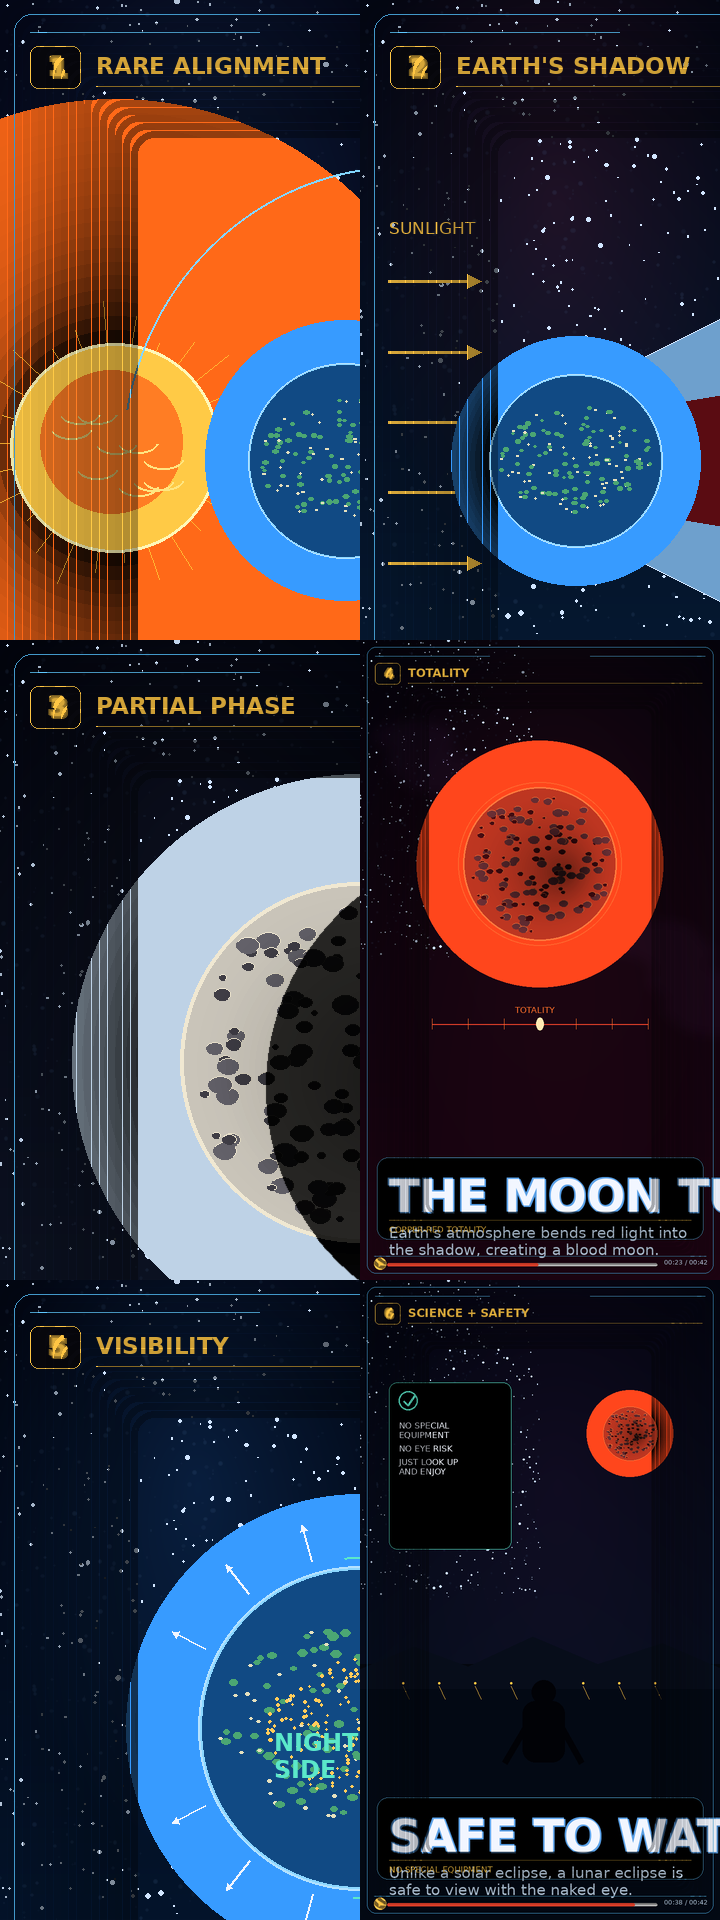

In [10]:
# ==========================
# Render storyboard preview
# ==========================
preview_times = [0.8, 7.4, 15.0, 23.5, 31.0, 38.5]
frames = [Image.fromarray(make_frame(int(t * FPS))) for t in preview_times]
thumb_w = W // 2
thumb_h = H // 2
contact = Image.new("RGB", (thumb_w * 2, thumb_h * 3), (0, 0, 0))
try:
    RESAMPLE = Image.Resampling.LANCZOS
except Exception:
    RESAMPLE = Image.LANCZOS
for idx, frame in enumerate(frames):
    thumb = frame.resize((thumb_w, thumb_h), RESAMPLE)
    contact.paste(thumb, ((idx % 2) * thumb_w, (idx // 2) * thumb_h))
contact.save(STORYBOARD_NAME, quality=95)
print(f"Saved storyboard preview: {STORYBOARD_NAME}")
contact


In [11]:
# ==========================
# Render the full vertical video
# ==========================
# Tip: keep DRAFT_MODE=True for testing. Set DRAFT_MODE=False in the config cell for a sharper final export.
writer = imageio.get_writer(
    VIDEO_NAME,
    fps=FPS,
    codec="libx264",
    quality=8 if DRAFT_MODE else 9,
    pixelformat="yuv420p",
    macro_block_size=16,
)

for frame_idx in tqdm(range(NFRAMES), desc="Rendering lunar eclipse cinematic short"):
    writer.append_data(make_frame(frame_idx))
writer.close()

print(f"Saved video: {VIDEO_NAME}")
print(f"Duration: {VIDEO_SECONDS:.1f}s | FPS: {FPS} | Size: {W}x{H}")


Rendering lunar eclipse cinematic short:   0%|          | 0/1008 [00:00<?, ?it/s]

ValueError: All images in a movie should have same size

In [ ]:
# Display video inside the notebook, if supported
from IPython.display import Video, display

display(Video(str(VIDEO_NAME), embed=True, html_attributes="controls autoplay loop"))


## Easy ways to customize

Edit only the `SCENES` list in the config cell to change text timing and captions. The visuals are tied to each scene's `kind`, so the video stays cinematic even if you rewrite the script.

Scene kinds available in this notebook:

- `alignment`
- `shadow_geometry`
- `partial_phase`
- `totality`
- `visibility`
- `safe_science`

For a stronger Shorts style, keep captions short and punchy. For a documentary style, make the captions longer and set `VIDEO_SECONDS` to 60.
